# OHLC Conditional — CSV-based Analysis

Loads pre-generated samples from CSV files produced by `generate_samples.py`
and compares the generated Close paths against ground-truth Close.

No model inference is performed here — just load, parse, and analyse.

Expected CSVs (under `<GEN_DIR>/<CHECKPOINT_STEM>/`):
- `train_generated_close.csv` — generated Close paths for training windows
- `train_gt_ohlc.csv`         — ground-truth OHLC context for training windows
- `val_generated_close.csv`   — generated Close paths for validation windows
- `val_gt_ohlc.csv`           — ground-truth OHLC context for validation windows

CSV schemas
-----------
`*_generated_close.csv`: `window_idx | sample_idx | file | window_start | step_000 … step_{L-1}`

`*_gt_ohlc.csv`: `window_idx | feature | file | window_start | step_000 … step_{L-1}`

In [44]:
# ── USER INPUTS ───────────────────────────────────────────────────────────────
CHECKPOINT_STEM = (
    "NO_NO_FAKE_FTS_PROC_CLOS_ep-100_20260407_192135"
)  # <-- sub-folder name under GEN_DIR (= checkpoint filename without .pt)

GEN_DIR = "../data/generated/conditional"  # base directory where generate_samples.py writes

SPLIT   = "val"   # "train" | "val" | "both"  — which split(s) to analyse
# ─────────────────────────────────────────────────────────────────────────────

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from statsmodels.tsa.stattools import acf

ckpt_dir = os.path.join(GEN_DIR, CHECKPOINT_STEM)
assert os.path.isdir(ckpt_dir), f"Directory not found: {ckpt_dir}"
print(f"Reading from: {ckpt_dir}")

Reading from: ../data/generated/conditional\NO_NO_FAKE_FTS_PROC_CLOS_ep-100_20260407_192135


## 1. Load CSVs

In [46]:
def load_split(split, ckpt_dir):
    """
    Load one split's generated-close and GT-OHLC CSVs.

    Returns
    -------
    df_gen  : DataFrame  (window_idx, sample_idx, file, window_start, step_*)
    df_ohlc : DataFrame  (window_idx, feature, file, window_start, step_*)
    step_cols : list of step column names
    """
    gen_path  = os.path.join(ckpt_dir, f"{split}_generated_close.csv")
    ohlc_path = os.path.join(ckpt_dir, f"{split}_gt_ohlc.csv")

    assert os.path.isfile(gen_path),  f"Not found: {gen_path}"
    assert os.path.isfile(ohlc_path), f"Not found: {ohlc_path}"

    df_gen  = pd.read_csv(gen_path)
    df_ohlc = pd.read_csv(ohlc_path)

    step_cols = [c for c in df_gen.columns if c.startswith("step_")]
    seq_len   = len(step_cols)

    n_windows = df_gen["window_idx"].nunique()
    n_samples = df_gen["sample_idx"].nunique()
    features  = df_ohlc["feature"].unique().tolist()

    print(f"[{split}] windows={n_windows}  samples/window={n_samples}  "
          f"seq_len={seq_len}  features={features}")

    return df_gen, df_ohlc, step_cols


splits_to_run = ["train", "val"] if SPLIT == "both" else [SPLIT]
data = {}

for split in splits_to_run:
    try:
        df_gen, df_ohlc, step_cols = load_split(split, ckpt_dir)
        data[split] = (df_gen, df_ohlc, step_cols)
    except AssertionError as e:
        print(f"Skipping {split}: {e}")

[val] windows=20  samples/window=20  seq_len=64  features=['open', 'high', 'low', 'close']


## 2. Parse into NumPy arrays

Reshape DataFrames into `(n_windows, n_samples, seq_len)` for generated Close
and `(n_windows, seq_len)` per OHLC feature for ground-truth context.

In [47]:
def parse_arrays(df_gen, df_ohlc, step_cols):
    """
    Returns
    -------
    gen_3d   : (n_windows, n_samples, seq_len)  — generated Close
    gt_close : (n_windows, seq_len)             — ground-truth Close
    gt_open  : (n_windows, seq_len)
    gt_high  : (n_windows, seq_len)
    gt_low   : (n_windows, seq_len)
    window_ids : list of window_idx values (sorted)
    """
    window_ids = sorted(df_gen["window_idx"].unique())
    n_windows  = len(window_ids)
    n_samples  = df_gen["sample_idx"].nunique()
    seq_len    = len(step_cols)

    gen_3d = np.zeros((n_windows, n_samples, seq_len), dtype=np.float32)
    for wi, wid in enumerate(window_ids):
        sub = df_gen[df_gen["window_idx"] == wid].sort_values("sample_idx")
        gen_3d[wi] = sub[step_cols].to_numpy(dtype=np.float32)

    def gt_feat(feat_name):
        sub = df_ohlc[df_ohlc["feature"] == feat_name].sort_values("window_idx")
        return sub[step_cols].to_numpy(dtype=np.float32)   # (n_windows, seq_len)

    gt_open  = gt_feat("open")
    gt_high  = gt_feat("high")
    gt_low   = gt_feat("low")
    gt_close = gt_feat("close")

    return gen_3d, gt_close, gt_open, gt_high, gt_low, window_ids


parsed = {}
for split, (df_gen, df_ohlc, step_cols) in data.items():
    parsed[split] = parse_arrays(df_gen, df_ohlc, step_cols)
    gen_3d, gt_close, gt_open, gt_high, gt_low, window_ids = parsed[split]
    print(f"[{split}] gen_3d={gen_3d.shape}  gt_close={gt_close.shape}")

[val] gen_3d=(20, 20, 64)  gt_close=(20, 64)


---
## Analyses

The cells below run on the **first available split** by default.  
Change `ANALYSIS_SPLIT` to switch between `"train"` / `"val"`.

In [48]:
ANALYSIS_SPLIT = splits_to_run[0]   # change to "val" if needed

gen_3d, gt_close, gt_open, gt_high, gt_low, window_ids = parsed[ANALYSIS_SPLIT]
n_windows, n_samples, seq_len = gen_3d.shape
steps = np.arange(seq_len)

# Flat 2-D views for distribution-level comparisons
all_gen_close = gen_3d.reshape(n_windows * n_samples, seq_len)   # (N*B, L)
all_gt_close  = np.repeat(gt_close, n_samples, axis=0)           # (N*B, L)
all_gt_high   = np.repeat(gt_high,  n_samples, axis=0)
all_gt_low    = np.repeat(gt_low,   n_samples, axis=0)

print(f"Split         : {ANALYSIS_SPLIT}")
print(f"n_windows     : {n_windows}")
print(f"n_samples     : {n_samples}")
print(f"seq_len       : {seq_len}")
print(f"all_gen_close : {all_gen_close.shape}")

Split         : val
n_windows     : 20
n_samples     : 20
seq_len       : 64
all_gen_close : (400, 64)


## 3. Sample path overlays

For each shown window: ground-truth OHL band + GT Close (top row) vs
GT OHL band + all generated Close samples (bottom row).

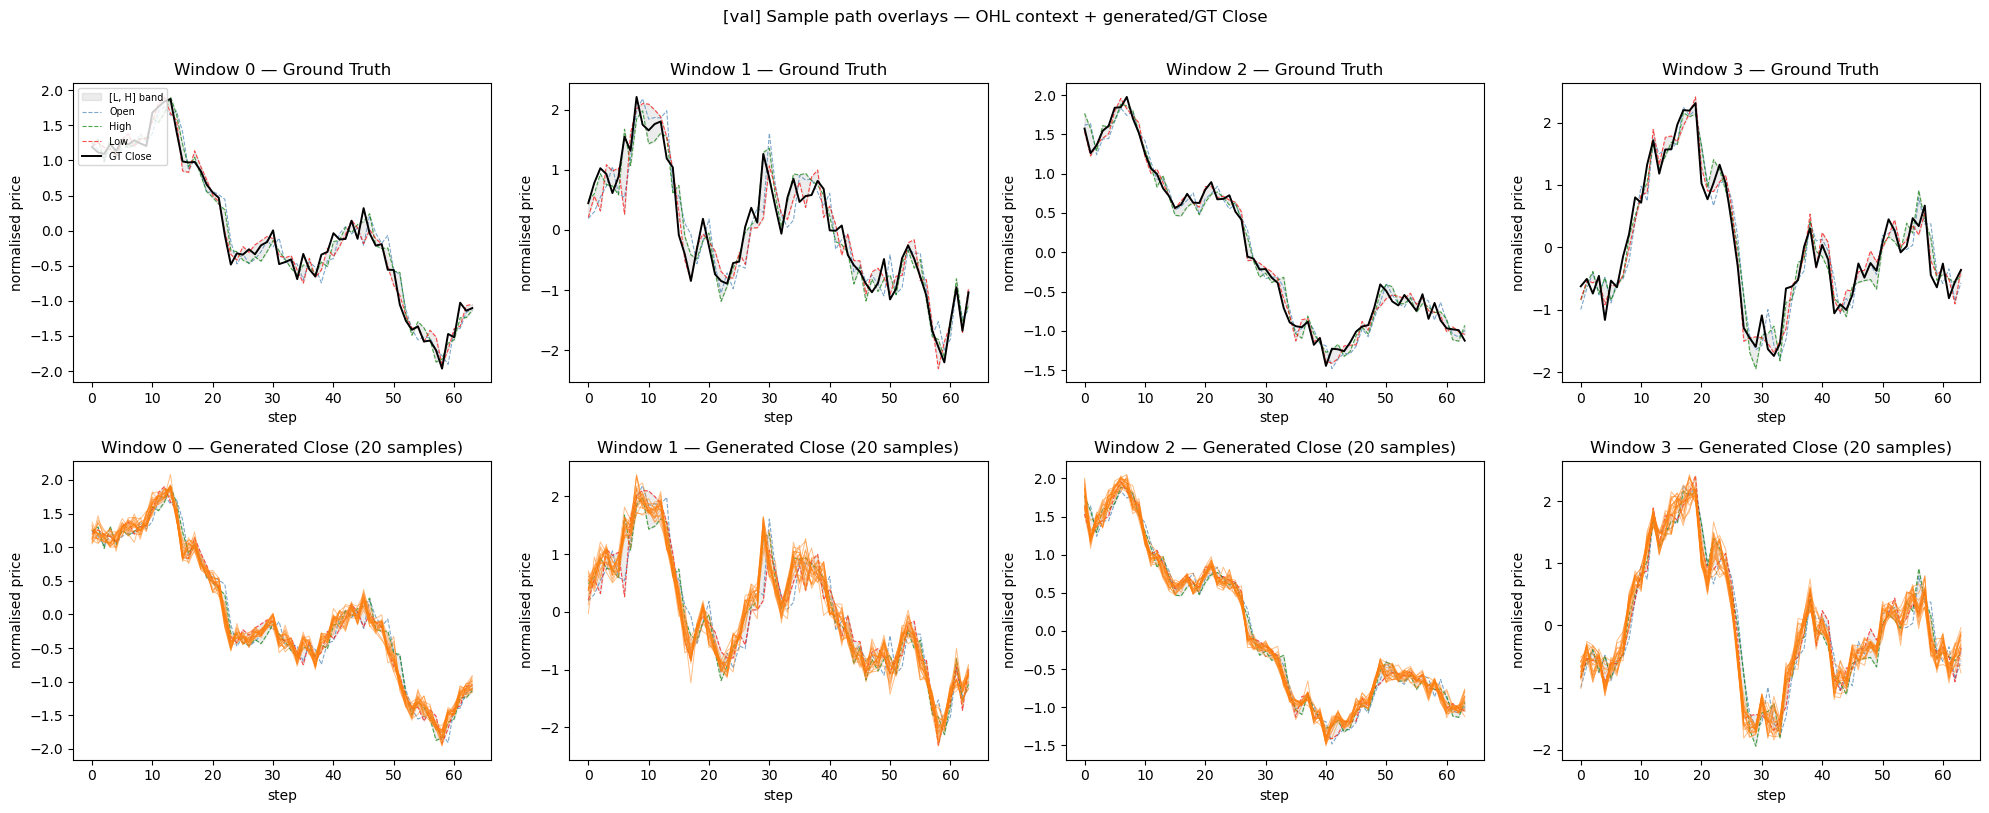

In [49]:
N_SHOW  = min(n_windows, 4)   # windows to display side-by-side
n_rows  = 2

fig, axes = plt.subplots(n_rows, N_SHOW, figsize=(5 * N_SHOW, 4 * n_rows), sharey=False)
if N_SHOW == 1:
    axes = axes.reshape(n_rows, 1)

for col, w in enumerate(range(N_SHOW)):
    for ax in axes[:, col]:
        ax.fill_between(steps, gt_low[w], gt_high[w],
                        alpha=0.15, color="gray", label="[L, H] band")
        ax.plot(steps, gt_open[w],  color="steelblue",  lw=0.8, ls="--", alpha=0.7, label="Open")
        ax.plot(steps, gt_high[w],  color="green",      lw=0.8, ls="--", alpha=0.7, label="High")
        ax.plot(steps, gt_low[w],   color="red",        lw=0.8, ls="--", alpha=0.7, label="Low")

    # Top row: ground-truth Close
    axes[0, col].plot(steps, gt_close[w], color="black", lw=1.4, label="GT Close")
    axes[0, col].set_title(f"Window {window_ids[w]} — Ground Truth")

    # Bottom row: all generated Close samples
    for s in range(n_samples):
        axes[1, col].plot(steps, gen_3d[w, s], color="tab:orange", lw=0.7, alpha=0.5)
    axes[1, col].set_title(f"Window {window_ids[w]} — Generated Close ({n_samples} samples)")

axes[0, 0].legend(fontsize=7, loc="upper left")
for ax in axes.ravel():
    ax.set_xlabel("step")
    ax.set_ylabel("normalised price")

plt.suptitle(f"[{ANALYSIS_SPLIT}] Sample path overlays — OHL context + generated/GT Close", y=1.01)
plt.tight_layout()
plt.show()

## 4. OHLC constraint satisfaction

Checks whether the generated Close satisfies `L ≤ Close ≤ H`.

> Note: data are normalised column-wise, so this constraint can be broken locally even for perfectly generated samples — treat the rate as a diagnostic, not an absolute criterion.

  OHLC CONSTRAINT  L ≤ Close ≤ H
  Step-wise satisfaction rate : 0.1198
  Fully valid samples         : 0.0000


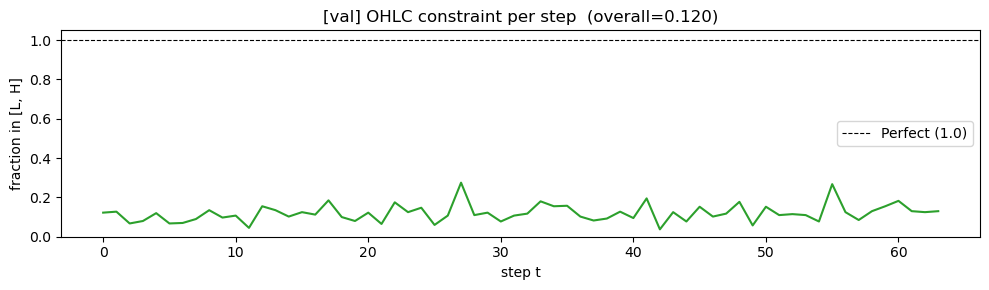

In [50]:
above_low  = all_gen_close >= all_gt_low
below_high = all_gen_close <= all_gt_high
in_band    = above_low & below_high

step_rate   = in_band.mean(axis=0)   # (seq_len,)
fully_valid = in_band.all(axis=1).mean()
stepwise    = in_band.mean()

print("=" * 55)
print("  OHLC CONSTRAINT  L ≤ Close ≤ H")
print("=" * 55)
print(f"  Step-wise satisfaction rate : {stepwise:.4f}")
print(f"  Fully valid samples         : {fully_valid:.4f}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(steps, step_rate, color="tab:green", lw=1.5)
ax.axhline(1.0, color="black", lw=0.8, ls="--", label="Perfect (1.0)")
ax.set_ylim(0, 1.05)
ax.set_xlabel("step t")
ax.set_ylabel("fraction in [L, H]")
ax.set_title(f"[{ANALYSIS_SPLIT}] OHLC constraint per step  (overall={stepwise:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Marginal distribution of Close values

KS statistic = 0.0121  |  p-value = 4.7611e-02



,mean,std,skewness,excess_kurtosis,q01,q99
label,,,,,,
Generated Close,0.00749,0.99229,0.21881,-0.80220,-1.85783,2.10372
Ground-truth Close,-0.00000,1.00000,0.18351,-0.77983,-1.94337,2.11726


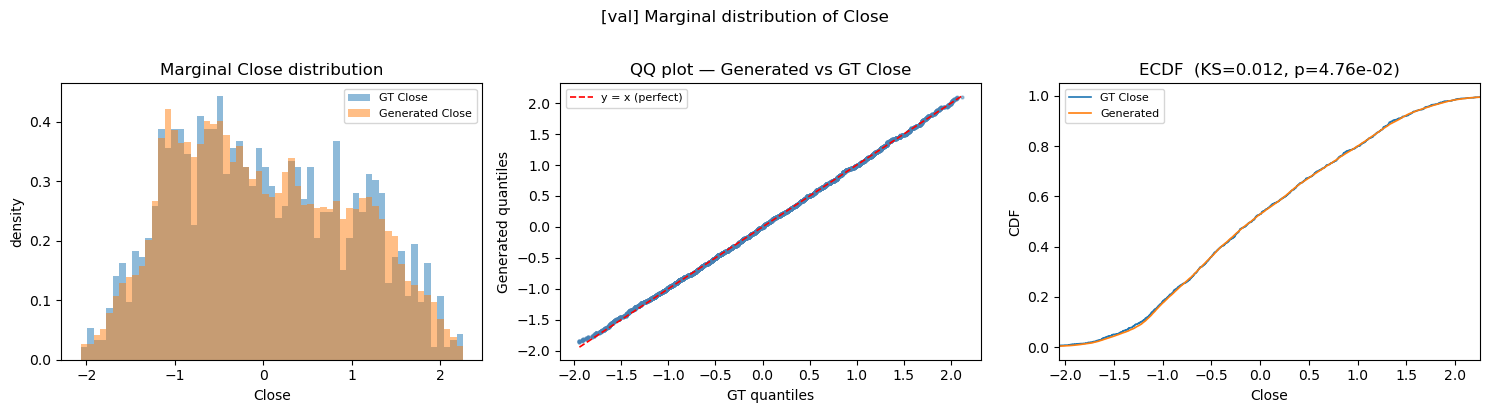

In [51]:
gen_flat = all_gen_close.ravel()
gt_flat  = all_gt_close.ravel()

ks_stat, ks_p = scipy_stats.ks_2samp(gen_flat, gt_flat)

def moments(x, label):
    return {
        "label"           : label,
        "mean"            : np.mean(x),
        "std"             : np.std(x),
        "skewness"        : scipy_stats.skew(x),
        "excess_kurtosis" : scipy_stats.kurtosis(x, fisher=True),
        "q01"             : np.quantile(x, 0.01),
        "q99"             : np.quantile(x, 0.99),
    }

df_moments = pd.DataFrame([
    moments(gen_flat, "Generated Close"),
    moments(gt_flat,  "Ground-truth Close"),
]).set_index("label").round(5)

print(f"KS statistic = {ks_stat:.4f}  |  p-value = {ks_p:.4e}")
print()
display(df_moments)

combined = np.concatenate([gen_flat, gt_flat])
lo, hi   = np.quantile(combined, [0.005, 0.995])
bins     = np.linspace(lo, hi, 60)
probs    = np.linspace(0.01, 0.99, min(len(gen_flat), 5_000))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(gt_flat,  bins=bins, density=True, alpha=0.5, label="GT Close",        color="tab:blue")
ax.hist(gen_flat, bins=bins, density=True, alpha=0.5, label="Generated Close", color="tab:orange")
ax.set_title("Marginal Close distribution")
ax.set_xlabel("Close"); ax.set_ylabel("density"); ax.legend(fontsize=8)

ax = axes[1]
q_gt  = np.quantile(gt_flat,  probs)
q_gen = np.quantile(gen_flat, probs)
ax.scatter(q_gt, q_gen, s=4, alpha=0.5, color="steelblue")
lims = [min(q_gt.min(), q_gen.min()), max(q_gt.max(), q_gen.max())]
ax.plot(lims, lims, "r--", lw=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — Generated vs GT Close")
ax.set_xlabel("GT quantiles"); ax.set_ylabel("Generated quantiles"); ax.legend(fontsize=8)

ax = axes[2]
for vals, label, color in [(gt_flat, "GT Close", "tab:blue"), (gen_flat, "Generated", "tab:orange")]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, lw=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF  (KS={ks_stat:.3f}, p={ks_p:.2e})")
ax.set_xlabel("Close"); ax.set_ylabel("CDF"); ax.legend(fontsize=8)

plt.suptitle(f"[{ANALYSIS_SPLIT}] Marginal distribution of Close", y=1.02)
plt.tight_layout()
plt.show()

## 6. Close increments distribution and ACF

Increment KS = 0.0241  p = 8.3671e-07


,mean,std,skewness,excess_kurtosis,q01,q99
label,,,,,,
Generated ΔClose,-0.00221,0.36332,0.03265,1.10010,-0.93124,0.95209
GT ΔClose,-0.00240,0.37475,0.08023,1.06697,-0.98915,1.01317


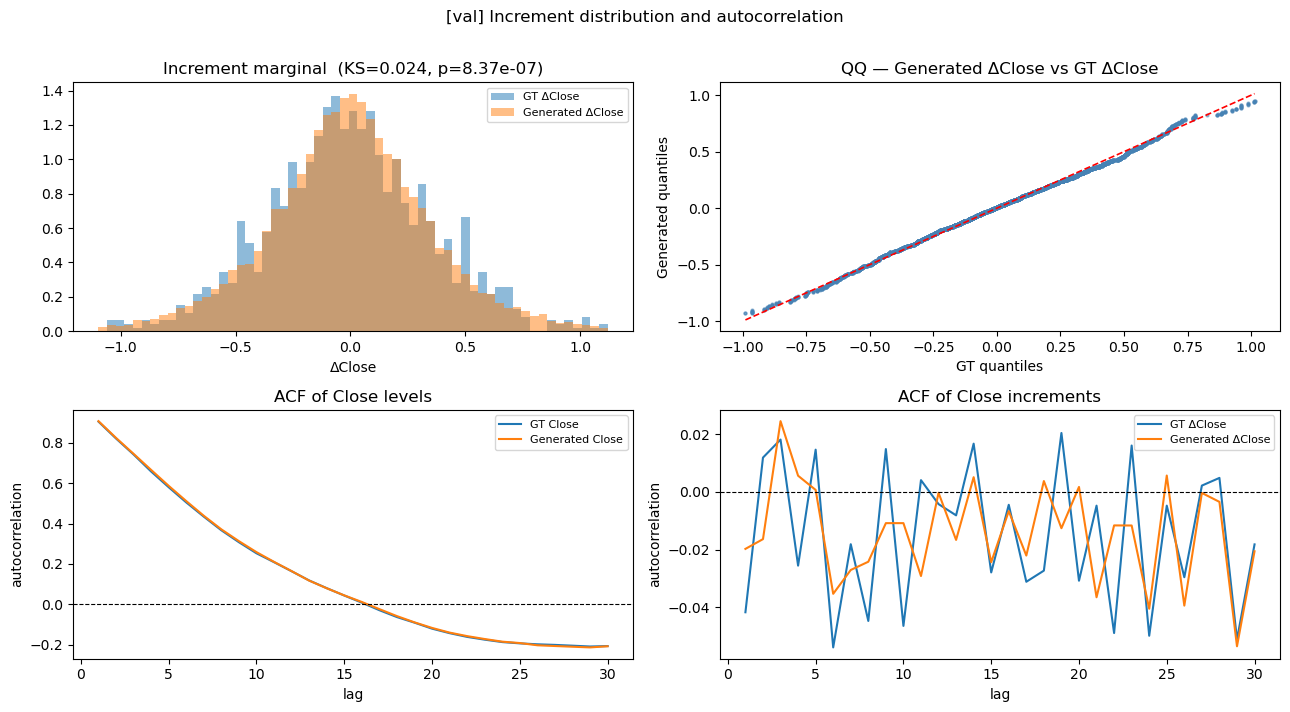

In [52]:
gen_inc = np.diff(all_gen_close, axis=1).ravel()
gt_inc  = np.diff(all_gt_close,  axis=1).ravel()

ks_inc, ks_p_inc = scipy_stats.ks_2samp(gen_inc, gt_inc)
print(f"Increment KS = {ks_inc:.4f}  p = {ks_p_inc:.4e}")

df_inc = pd.DataFrame([
    moments(gen_inc, "Generated ΔClose"),
    moments(gt_inc,  "GT ΔClose"),
]).set_index("label").round(5)
display(df_inc)

N_ACF    = min(50, n_windows)
LAGS     = min(30, seq_len // 2)
lag_axis = np.arange(1, LAGS + 1)

def mean_acf(paths, lags, use_diff=False):
    acfs = []
    for p in paths[:N_ACF]:
        x = np.diff(p) if use_diff else p
        acfs.append(acf(x, nlags=lags, fft=True)[1:])
    return np.mean(acfs, axis=0)

# For ACF we pick one sample per window (sample 0) to avoid repetition artefacts
gen_paths_s0 = gen_3d[:, 0, :]   # (n_windows, seq_len)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

lo_i, hi_i = np.quantile(np.concatenate([gen_inc, gt_inc]), [0.005, 0.995])
bins_i = np.linspace(lo_i, hi_i, 60)
axes[0, 0].hist(gt_inc,  bins=bins_i, density=True, alpha=0.5, label="GT ΔClose",        color="tab:blue")
axes[0, 0].hist(gen_inc, bins=bins_i, density=True, alpha=0.5, label="Generated ΔClose", color="tab:orange")
axes[0, 0].set_title(f"Increment marginal  (KS={ks_inc:.3f}, p={ks_p_inc:.2e})")
axes[0, 0].set_xlabel("ΔClose"); axes[0, 0].legend(fontsize=8)

probs_i = np.linspace(0.01, 0.99, min(len(gen_inc), 5_000))
q_gt_i  = np.quantile(gt_inc,  probs_i)
q_gen_i = np.quantile(gen_inc, probs_i)
axes[0, 1].scatter(q_gt_i, q_gen_i, s=4, alpha=0.5, color="steelblue")
lims_i = [min(q_gt_i.min(), q_gen_i.min()), max(q_gt_i.max(), q_gen_i.max())]
axes[0, 1].plot(lims_i, lims_i, "r--", lw=1.2)
axes[0, 1].set_title("QQ — Generated ΔClose vs GT ΔClose")
axes[0, 1].set_xlabel("GT quantiles"); axes[0, 1].set_ylabel("Generated quantiles")

axes[1, 0].plot(lag_axis, mean_acf(gt_close,      LAGS, use_diff=False), label="GT Close",        color="tab:blue")
axes[1, 0].plot(lag_axis, mean_acf(gen_paths_s0,  LAGS, use_diff=False), label="Generated Close", color="tab:orange")
axes[1, 0].axhline(0, color="black", lw=0.8, ls="--")
axes[1, 0].set_title("ACF of Close levels")
axes[1, 0].set_xlabel("lag"); axes[1, 0].set_ylabel("autocorrelation"); axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(lag_axis, mean_acf(gt_close,      LAGS, use_diff=True), label="GT ΔClose",        color="tab:blue")
axes[1, 1].plot(lag_axis, mean_acf(gen_paths_s0,  LAGS, use_diff=True), label="Generated ΔClose", color="tab:orange")
axes[1, 1].axhline(0, color="black", lw=0.8, ls="--")
axes[1, 1].set_title("ACF of Close increments")
axes[1, 1].set_xlabel("lag"); axes[1, 1].set_ylabel("autocorrelation"); axes[1, 1].legend(fontsize=8)

plt.suptitle(f"[{ANALYSIS_SPLIT}] Increment distribution and autocorrelation", y=1.01)
plt.tight_layout()
plt.show()

## 7. Per-step conditional mean ± std

At each timestep: generated sample mean vs GT Close, with ±1 std band.

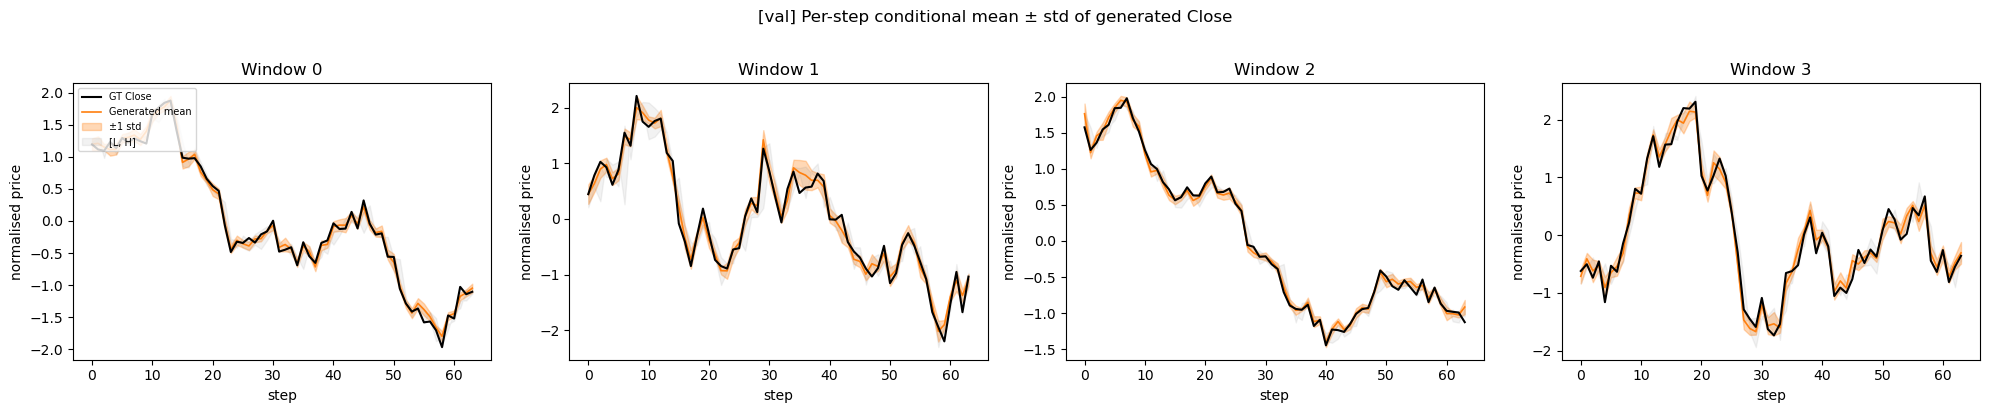

Mean absolute error  (generated mean vs GT): 0.08915
RMSE                 (generated mean vs GT): 0.12031
Mean generated std   (residual uncertainty): 0.10243


In [53]:
gen_mean = gen_3d.mean(axis=1)   # (n_windows, seq_len)
gen_std  = gen_3d.std(axis=1)    # (n_windows, seq_len)

N_SHOW2 = min(n_windows, 4)
fig, axes = plt.subplots(1, N_SHOW2, figsize=(5 * N_SHOW2, 4), sharey=False)
if N_SHOW2 == 1:
    axes = [axes]

for col, w in enumerate(range(N_SHOW2)):
    ax = axes[col]
    ax.plot(steps, gt_close[w],  color="black",      lw=1.5, label="GT Close",       zorder=3)
    ax.plot(steps, gen_mean[w],  color="tab:orange", lw=1.2, label="Generated mean", zorder=2)
    ax.fill_between(
        steps,
        gen_mean[w] - gen_std[w],
        gen_mean[w] + gen_std[w],
        alpha=0.3, color="tab:orange", label="±1 std"
    )
    ax.fill_between(steps, gt_low[w], gt_high[w], alpha=0.10, color="gray", label="[L, H]")
    ax.set_title(f"Window {window_ids[w]}")
    ax.set_xlabel("step")
    ax.set_ylabel("normalised price")

axes[0].legend(fontsize=7, loc="upper left")
plt.suptitle(f"[{ANALYSIS_SPLIT}] Per-step conditional mean ± std of generated Close", y=1.02)
plt.tight_layout()
plt.show()

mae  = np.abs(gen_mean - gt_close).mean()
rmse = np.sqrt(((gen_mean - gt_close) ** 2).mean())
print(f"Mean absolute error  (generated mean vs GT): {mae:.5f}")
print(f"RMSE                 (generated mean vs GT): {rmse:.5f}")
print(f"Mean generated std   (residual uncertainty): {gen_std.mean():.5f}")

## 8. Train vs Val comparison (requires SPLIT="both")

Side-by-side summary statistics for train and validation splits.

In [54]:
if len(parsed) < 2:
    print("Set SPLIT='both' at the top to enable train/val comparison.")
else:
    rows = []
    for sp, (g3d, gtc, gto, gth, gtl, wids) in parsed.items():
        nw, ns, sl = g3d.shape
        gen_all = g3d.reshape(nw * ns, sl)
        gt_all  = np.repeat(gtc, ns, axis=0)
        ks, ks_p  = scipy_stats.ks_2samp(gen_all.ravel(), gt_all.ravel())
        gm = g3d.mean(axis=1)
        mae  = np.abs(gm - gtc).mean()
        rmse = np.sqrt(((gm - gtc) ** 2).mean())
        in_b = ((gen_all >= np.repeat(gtl, ns, axis=0)) &
                (gen_all <= np.repeat(gth, ns, axis=0))).mean()
        rows.append({
            "split"          : sp,
            "n_windows"      : nw,
            "n_samples"      : ns,
            "KS stat"        : round(ks, 4),
            "KS p-value"     : f"{ks_p:.2e}",
            "MAE (mean vs GT)": round(mae, 5),
            "RMSE"           : round(rmse, 5),
            "OHLC step rate" : round(float(in_b), 4),
        })
    display(pd.DataFrame(rows).set_index("split"))

Set SPLIT='both' at the top to enable train/val comparison.


## Interpretation guide

| Test | Passing (overfit / well-conditioned) | Failing |
|------|--------------------------------------|---------|
| **Sample paths** (§3) | Generated Close tracks GT inside [L,H] | Paths wander outside [L,H] or uncorrelated with GT |
| **OHLC constraint** (§4) | Step-wise rate > 0.90 | Rate < 0.5 → model ignores OHL context |
| **Marginal KS** (§5) | KS p > 0.05; QQ on diagonal | S-curve in QQ (wrong tail shape) |
| **Increment KS** (§6) | KS p > 0.05; similar std | Generated std much larger → noise not removed |
| **Level ACF** (§6) | Generated ACF tracks GT shape | Flat or too fast decay → wrong temporal structure |
| **Increment ACF** (§6) | Both near 0 at all lags | Positive lags → spurious momentum |
| **Per-step mean** (§7) | MAE near 0; small residual std | Large MAE → bad conditioning; large std → excess uncertainty |